# Task B1:
Apply the three smoothing filters: averaging filter, Gaussian filter and median filter to the downloaded grayscale image. For each filter, using three kernel sizes: 3x3, 5x5, 9x9. Then,
- Display the original image and all filtered images.
- Compare the visual differences between the filtered images.
- Explain how the kernel size affects image details and blurring.

### The original image

In [152]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math
import random

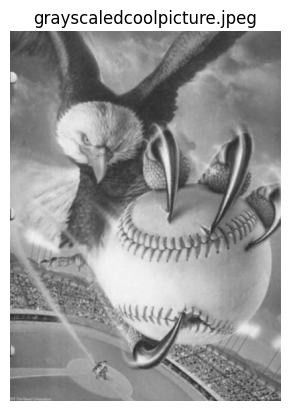

In [153]:
image = cv2.imread("grayscaledcoolpicture.jpeg")

plt.imshow(image)
plt.axis("off")
plt.title("grayscaledcoolpicture.jpeg")
plt.show()

### The kernels

In [154]:
def average_kernel(size):
    kernel = np.ones((size,size))
    return kernel / kernel.sum()

def gaussian_kernel(size):
    row = np.array([math.comb(size - 1, k) for k in range(size)])
    kernel = np.outer(row, row)
    return kernel / kernel.sum()

### The filters

#### Averaging filter

In [155]:
def average_filter(image,size):
    for i in range(size//2, image.shape[0] - size//2):
        for j in range(size//2, image.shape[1] - size//2):
            window=image[i-size//2:i+((size//2)+1), j-size//2:j+((size//2)+1), 0]
            average=(window*average_kernel(size)).sum()
            image[i, j]=average

In [156]:
avg_result_3x3=image.copy()
avg_result_5x5=image.copy()
avg_result_9x9=image.copy()

average_filter(avg_result_3x3,3)
average_filter(avg_result_5x5,5)
average_filter(avg_result_9x9,9)

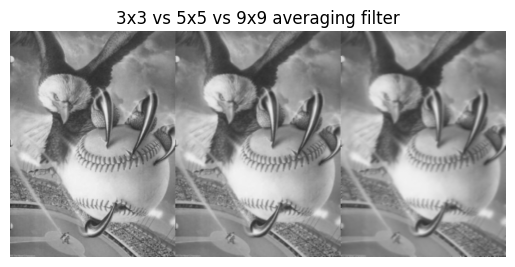

In [157]:
comp_average = np.hstack((avg_result_3x3,avg_result_5x5,avg_result_9x9))

plt.imshow(comp_average)
plt.axis("off")
plt.title("3x3 vs 5x5 vs 9x9 averaging filter")
plt.show()

#### Gaussian filter

In [158]:
def gaussian_filter(image,size):
    for i in range(size//2, image.shape[0] - size//2):
        for j in range(size//2, image.shape[1] - size//2):
            window=image[i-size//2:i+((size//2)+1), j-size//2:j+((size//2)+1), 0]
            gaussian=(window*gaussian_kernel(size)).sum()
            image[i, j]=gaussian

In [159]:
gas_result_3x3=image.copy()
gas_result_5x5=image.copy()
gas_result_9x9=image.copy()

gaussian_filter(gas_result_3x3,3)
gaussian_filter(gas_result_5x5,5)
gaussian_filter(gas_result_9x9,9)

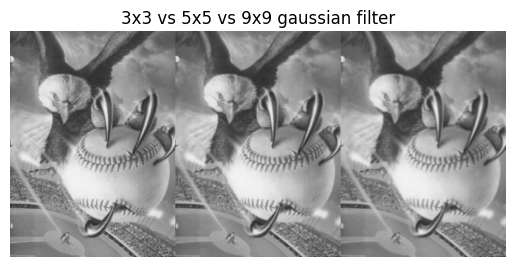

In [160]:
comp_gaussian = np.hstack((gas_result_3x3,gas_result_5x5,gas_result_9x9))

plt.imshow(comp_gaussian)
plt.axis("off")
plt.title("3x3 vs 5x5 vs 9x9 gaussian filter")
plt.show()

#### Median filter

In [161]:
def median_filter(image,size):
    for i in range(size//2, image.shape[0] - size//2):
        for j in range(size//2, image.shape[1] - size//2):
            window=image[i-size//2:i+((size//2)+1), j-size//2:j+((size//2)+1), 0]
            median=np.sort(window.ravel())
            image[i, j]=median[size*size//2]

In [162]:
med_result_3x3=image.copy()
med_result_5x5=image.copy()
med_result_9x9=image.copy()

median_filter(med_result_3x3,3)
median_filter(med_result_5x5,5)
median_filter(med_result_9x9,9)

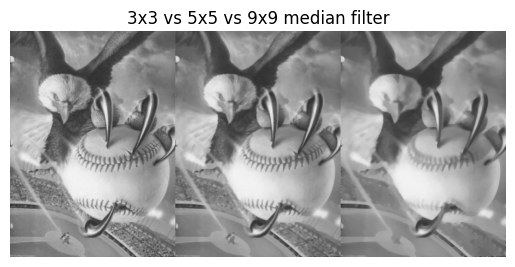

In [163]:
comp_median = np.hstack((med_result_3x3,med_result_5x5,med_result_9x9))

plt.imshow(comp_median)
plt.axis("off")
plt.title("3x3 vs 5x5 vs 9x9 median filter")
plt.show()

### => The bigger the kernel size is, the more blurry the image gets

# Task B2:
Create three noisy versions of the grayscale image: image with Gaussian noise; image with salt-and-pepper noise; and image with periodic noise. Then,
- Display the original image and the three noisy images.
- Display the histogram of each original image and its corresponding noisy images.
- Explain on how each type of noise changes the image and its histogram.

### The original image

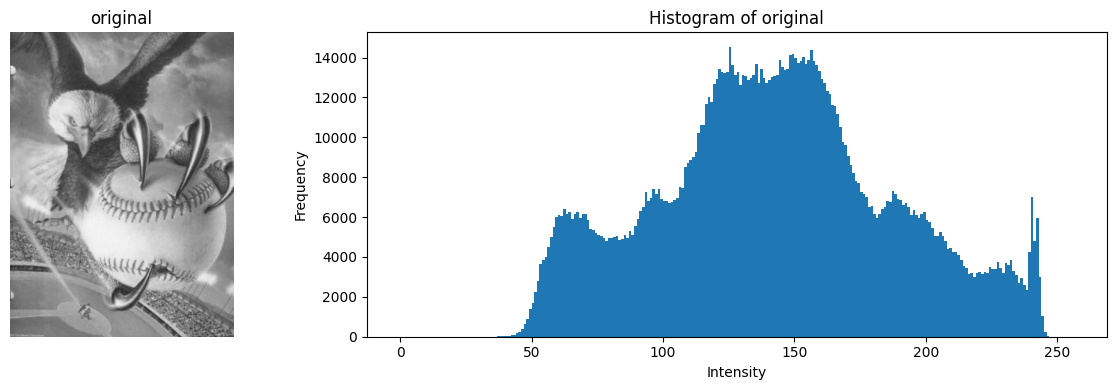

In [164]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    width_ratios=[1, 2]
)

# Image
axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title("original")

# Histogram
axes[1].hist(image.ravel(), bins=256, range=[0,256])
axes[1].set_title("Histogram of original")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### The noises

In [165]:
gaussian_noise = image.copy()
snp_noise = image.copy()
periodic_noise = image.copy()

#### Gaussian noise

In [166]:
# mean: Control where the noise value will be centered around
# std: Control the spread/strength of the noise
def add_gaussian_noise(image,mean,std):
    noise = np.random.normal(mean,std,size=(image.shape[0],image.shape[1]))
    noisy = image[:,:,0] + noise
    image[:,:,0] = noisy
    image[:,:,1] = noisy
    image[:,:,2] = noisy

add_gaussian_noise(gaussian_noise,0,30)

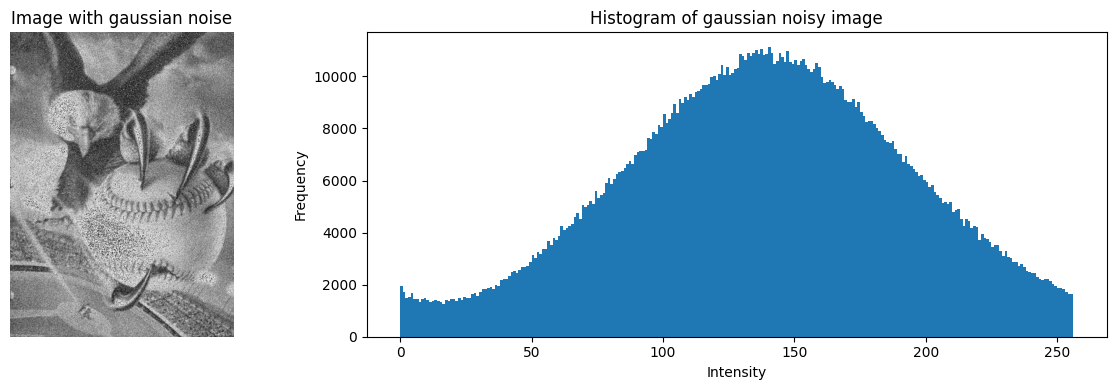

In [167]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    width_ratios=[1, 2]
)

# Image
axes[0].imshow(gaussian_noise)
axes[0].axis("off")
axes[0].set_title("Image with gaussian noise")

# Histogram
axes[1].hist(gaussian_noise.ravel(), bins=256, range=[0,256])
axes[1].set_title("Histogram of gaussian noisy image")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Gaussian noise changes the histogram of the image into a gaussian distribution

#### Salt and pepper noise

In [168]:
def add_snp_noise(image,salt,pepper):
    for i in range(salt):
        row=random.randint(0, image.shape[0]-1)
        col=random.randint(0, image.shape[1]-1)
        image[row, col]=255
    for i in range(pepper):
        row=random.randint(0, image.shape[0]-1)
        col=random.randint(0, image.shape[1]-1)
        image[row, col]=0

add_snp_noise(snp_noise,50000,50000)

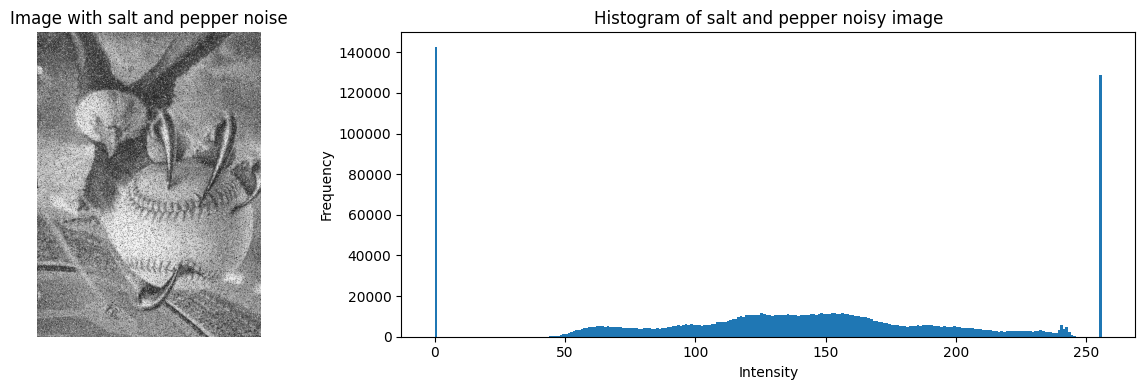

In [169]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    width_ratios=[1, 2]
)

# Image
axes[0].imshow(snp_noise)
axes[0].axis("off")
axes[0].set_title("Image with salt and pepper noise")

# Histogram
axes[1].hist(snp_noise.ravel(), bins=256, range=[0,256])
axes[1].set_title("Histogram of salt and pepper noisy image")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Salt and pepper noise moves the original intensity to either ends of the histogram

#### Periodic noise

In [170]:
# amplitude: Control the strength of the noise
# frequency: Control how often the pattern repeats
def add_periodic_noise(image, amplitude, frequency):
    x = np.arange(image.shape[1])
    periodic = amplitude * np.sin(2 * np.pi * frequency * x)
    periodic = np.tile(periodic, (image.shape[0], 1))
    noisy = image[:,:,0] + periodic
    image[:,:,0] = noisy
    image[:,:,1] = noisy
    image[:,:,2] = noisy

add_periodic_noise(periodic_noise,30,0.1)

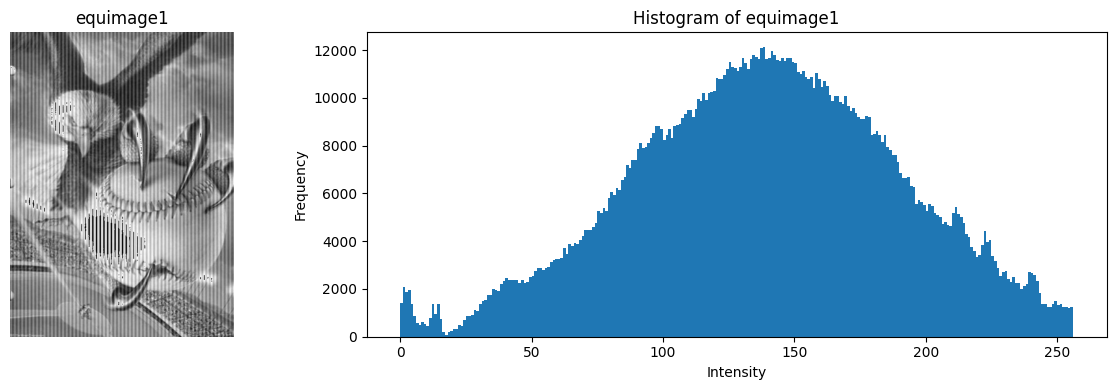

In [171]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    width_ratios=[1, 2]
)

# Image
axes[0].imshow(periodic_noise)
axes[0].axis("off")
axes[0].set_title("equimage1")

# Histogram
axes[1].hist(periodic_noise.ravel(), bins=256, range=[0,256])
axes[1].set_title("Histogram of equimage1")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The histogram of the periodic noise might look similar to the histogram of the gaussian noise, but looking at the image, we can see the pattern of the noise.

# Task B3:
Apply the three smoothing filters (averaging, Gaussian, median) to each noisy image using the three kernel sizes 3x3, 5x5, 9x9, then complete the following result table:

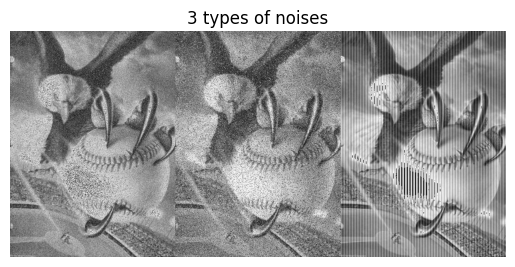

In [172]:
comp_noise = np.hstack((gaussian_noise,snp_noise,periodic_noise))

plt.imshow(comp_noise)
plt.axis("off")
plt.title("3 types of noises")
plt.show()

### Smoothing image with gaussian noise

In [173]:
gas_avg_3x3=gaussian_noise.copy()
gas_avg_5x5=gaussian_noise.copy()
gas_avg_9x9=gaussian_noise.copy()

gas_gas_3x3=gaussian_noise.copy()
gas_gas_5x5=gaussian_noise.copy()
gas_gas_9x9=gaussian_noise.copy()

gas_med_3x3=gaussian_noise.copy()
gas_med_5x5=gaussian_noise.copy()
gas_med_9x9=gaussian_noise.copy()

In [174]:
average_filter(gas_avg_3x3,3)
average_filter(gas_avg_5x5,5)
average_filter(gas_avg_9x9,9)

gaussian_filter(gas_gas_3x3,3)
gaussian_filter(gas_gas_5x5,5)
gaussian_filter(gas_gas_9x9,9)

median_filter(gas_med_3x3,3)
median_filter(gas_med_5x5,5)
median_filter(gas_med_9x9,9)

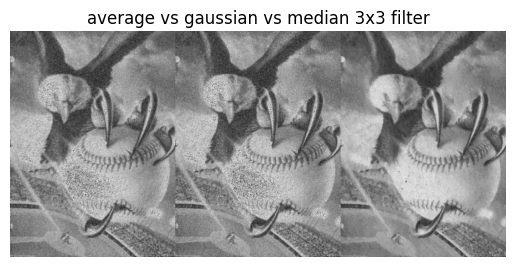

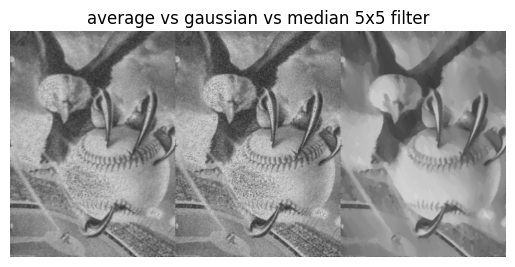

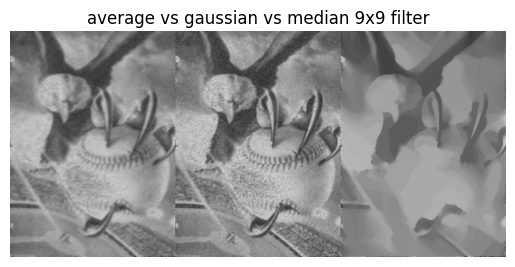

In [175]:
comp_gas_3x3 = np.hstack((gas_avg_3x3,gas_gas_3x3,gas_med_3x3))
comp_gas_5x5 = np.hstack((gas_avg_5x5,gas_gas_5x5,gas_med_5x5))
comp_gas_9x9 = np.hstack((gas_avg_9x9,gas_gas_9x9,gas_med_9x9))

plt.imshow(comp_gas_3x3)
plt.axis("off")
plt.title("average vs gaussian vs median 3x3 filter")
plt.show()

plt.imshow(comp_gas_5x5)
plt.axis("off")
plt.title("average vs gaussian vs median 5x5 filter")
plt.show()

plt.imshow(comp_gas_9x9)
plt.axis("off")
plt.title("average vs gaussian vs median 9x9 filter")
plt.show()

### Smoothing image with salt and pepper noise

In [176]:
snp_avg_3x3=snp_noise.copy()
snp_avg_5x5=snp_noise.copy()
snp_avg_9x9=snp_noise.copy()

snp_gas_3x3=snp_noise.copy()
snp_gas_5x5=snp_noise.copy()
snp_gas_9x9=snp_noise.copy()

snp_med_3x3=snp_noise.copy()
snp_med_5x5=snp_noise.copy()
snp_med_9x9=snp_noise.copy()

In [177]:
average_filter(snp_avg_3x3,3)
average_filter(snp_avg_5x5,5)
average_filter(snp_avg_9x9,9)

gaussian_filter(snp_gas_3x3,3)
gaussian_filter(snp_gas_5x5,5)
gaussian_filter(snp_gas_9x9,9)

median_filter(snp_med_3x3,3)
median_filter(snp_med_5x5,5)
median_filter(snp_med_9x9,9)

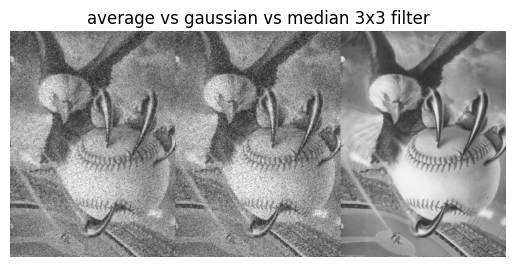

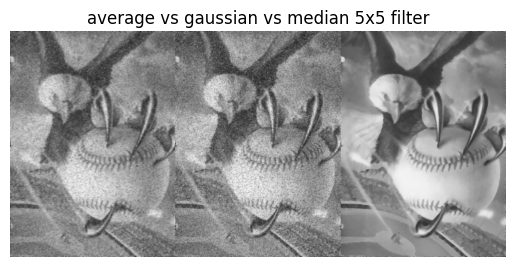

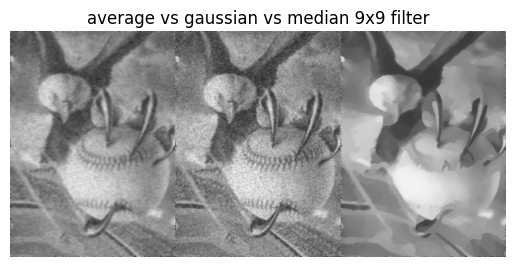

In [178]:
comp_snp_3x3 = np.hstack((snp_avg_3x3,snp_gas_3x3,snp_med_3x3))
comp_snp_5x5 = np.hstack((snp_avg_5x5,snp_gas_5x5,snp_med_5x5))
comp_snp_9x9 = np.hstack((snp_avg_9x9,snp_gas_9x9,snp_med_9x9))

plt.imshow(comp_snp_3x3)
plt.axis("off")
plt.title("average vs gaussian vs median 3x3 filter")
plt.show()

plt.imshow(comp_snp_5x5)
plt.axis("off")
plt.title("average vs gaussian vs median 5x5 filter")
plt.show()

plt.imshow(comp_snp_9x9)
plt.axis("off")
plt.title("average vs gaussian vs median 9x9 filter")
plt.show()

### Smoothing image with periodic noise

In [179]:
per_avg_3x3=periodic_noise.copy()
per_avg_5x5=periodic_noise.copy()
per_avg_9x9=periodic_noise.copy()

per_gas_3x3=periodic_noise.copy()
per_gas_5x5=periodic_noise.copy()
per_gas_9x9=periodic_noise.copy()

per_med_3x3=periodic_noise.copy()
per_med_5x5=periodic_noise.copy()
per_med_9x9=periodic_noise.copy()

In [180]:
average_filter(per_avg_3x3,3)
average_filter(per_avg_5x5,5)
average_filter(per_avg_9x9,9)

gaussian_filter(per_gas_3x3,3)
gaussian_filter(per_gas_5x5,5)
gaussian_filter(per_gas_9x9,9)

median_filter(per_med_3x3,3)
median_filter(per_med_5x5,5)
median_filter(per_med_9x9,9)

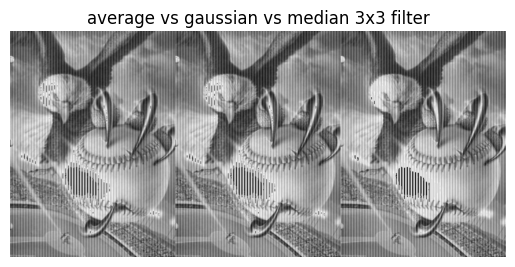

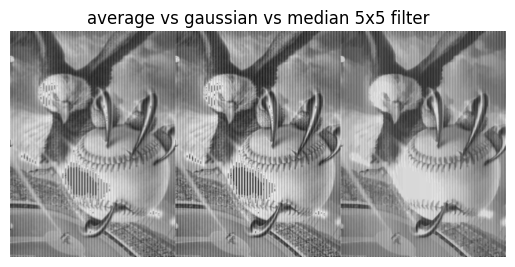

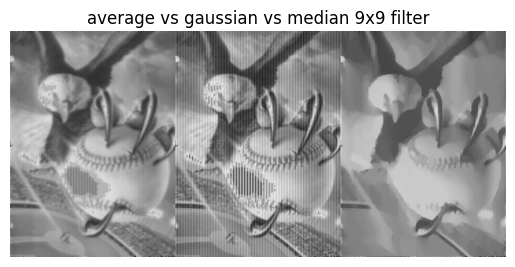

In [181]:
comp_per_3x3 = np.hstack((per_avg_3x3,per_gas_3x3,per_med_3x3))
comp_per_5x5 = np.hstack((per_avg_5x5,per_gas_5x5,per_med_5x5))
comp_per_9x9 = np.hstack((per_avg_9x9,per_gas_9x9,per_med_9x9))

plt.imshow(comp_per_3x3)
plt.axis("off")
plt.title("average vs gaussian vs median 3x3 filter")
plt.show()

plt.imshow(comp_per_5x5)
plt.axis("off")
plt.title("average vs gaussian vs median 5x5 filter")
plt.show()

plt.imshow(comp_per_9x9)
plt.axis("off")
plt.title("average vs gaussian vs median 9x9 filter")
plt.show()

#### => It seems that the median filter is the best for 3 types of noise